In [1]:
import numpy as np
from scipy.spatial.transform import Rotation as R

from numpy import savetxt
from res import RESERVOIRE_SIMPLE

import matplotlib.pyplot as plt
from numpy import linalg as LA

from nilearn import datasets, image, masking
import numpy as np

# Load Schaefer atlas (100-region, 7-network)
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
atlas_img = atlas['maps']
labels = atlas['labels']

input_factor = 0.

if_save_res = False
if_load_res = False

sigma_dynamics = .0

recurrent_factor = .1


[get_dataset_dir] Dataset found in /Users/cristianocapone/nilearn_data/schaefer_2018

In [2]:
import os
import numpy as np
from scipy.signal import butter, filtfilt

def lowpass_filter_rows(X, fs, cutoff, order=4):
    # X: N x T matrix
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    
    return np.array([filtfilt(b, a, row) for row in X])

# Example
fs = 1000        # sampling frequency (Hz)
cutoff = 150      # cutoff frequency (Hz)
# List all .npy files in processed_data folder, sorted alphabetically
processed_folder = "./processed_data"
#file_list = sorted([f for f in os.listdir(processed_folder) if f.endswith('.npy')])


def extract_leading_number(fname):
    try:
        return int(fname.split('_')[0])
    except ValueError:
        return float('inf')  # Put files without a leading number at the end

file_list = sorted(
    [f for f in os.listdir(processed_folder) if f.endswith('.npy')],
    key=extract_leading_number
)


collected_signals = []
for fname in file_list:

    arr = np.load(os.path.join(processed_folder, fname))
    #arr = (arr - arr.mean(axis=0)) / (arr.std(axis=0) + 1e-8)  # Centering and scaling
    #arr = lowpass_filter_rows(arr.T, fs, cutoff).T
    collected_signals.append(arr)
    print(f"Loaded {fname}, shape={arr.shape}")

Loaded 0_I281024_Resting_State_fMRI_20120127090933_501_timeseries.npy, shape=(140, 121)
Loaded 1_I330138_Resting_State_fMRI_20120801132156_501_timeseries.npy, shape=(140, 121)
Loaded 2_I306889_Resting_State_fMRI_20120529163501_501_timeseries.npy, shape=(140, 121)
Loaded 3_I375097_Resting_State_fMRI_20130603150048_501_timeseries.npy, shape=(140, 121)
Loaded 4_I352349_Resting_State_fMRI_20121211152153_501_timeseries.npy, shape=(140, 121)
Loaded 5_I333755_Resting_State_fMRI_20120911134450_501_timeseries.npy, shape=(140, 121)
Loaded 6_I404475_WIP_Resting_State_fMRI_20140110113148_601_timeseries.npy, shape=(140, 121)
Loaded 7_I286378_WIP_Resting_State_fMRI_20120223131712_501_timeseries.npy, shape=(140, 121)
Loaded 8_I286375_WIP_Resting_State_fMRI_20120223131712_601_timeseries.npy, shape=(140, 121)
Loaded 9_I269253_WIP_Resting_State_fMRI_20111116093525_701_timeseries.npy, shape=(140, 121)
Loaded 10_I269256_WIP_Resting_State_fMRI_20111116093525_601_timeseries.npy, shape=(140, 121)
Loaded 11_I

In [3]:

identifiers = np.load('identifiers.npy', allow_pickle=True)
patient_ID = [identifiers[k][1] for k in range(len(identifiers))]

In [4]:
len(identifiers)

908

In [5]:
state_ID = [identifiers[k][0] for k in range(len(identifiers))]

In [6]:
len(state_ID)

908

In [7]:
rec_type = [identifiers[k][2] for k in range(len(identifiers))]

In [8]:
# Filter indices where rec_type is 'Resting_State_fMRI'
#resting_indices = [i for i, r in enumerate(rec_type) if (r == 'Resting_State_fMRI' and np.shape(collected_signals[i])[0] > 100 and np.shape(collected_signals[i])[1] == 121)]
resting_indices = [i for i, r in enumerate(rec_type) if (np.shape(collected_signals[i])[0] > 100 and np.shape(collected_signals[i])[1] == 121)]

# Filter identifiers, patient_ID, and state_ID accordingly
identifiers_resting = [identifiers[i] for i in resting_indices]
patient_ID_resting = [identifiers[i][1] for i in resting_indices]
state_ID_resting = [identifiers[i][0] for i in resting_indices]
collected_signals_sel = [collected_signals[i] for i in resting_indices]
                

In [9]:
# Convert state_ID to numeric codes: 'AD' -> 0, 'CC' -> 1, 'MCI' -> 2
state_ID_numeric = []
for sid in state_ID_resting:
    if sid == 'CC':
        state_ID_numeric.append(0)
    elif sid == 'EMCI':
        state_ID_numeric.append(1)
    elif sid == 'MCI':
        state_ID_numeric.append(2)
    elif sid == 'LCMI':
        state_ID_numeric.append(3)
    elif sid == 'AD':
        state_ID_numeric.append(4)
    else:
        state_ID_numeric.append(-1)  # Unknown label

In [11]:
# Select only classes 0 and 4
selected_classes = [0,1,2,3,  4]
target_class = 4
selected_classes = [0, target_class  ]

filtered_indices = [i for i, c in enumerate(state_ID_numeric) if c in selected_classes]

# Apply the filter to all relevant lists
state_ID_numeric = [state_ID_numeric[i] for i in filtered_indices]
identifiers_resting = [identifiers_resting[i] for i in filtered_indices]
patient_ID_resting = [patient_ID_resting[i] for i in filtered_indices]
state_ID_resting = [state_ID_resting[i] for i in filtered_indices]
collected_signals_sel = [collected_signals_sel[i] for i in filtered_indices]


In [12]:
# Keep only the first recording for each patient

"""
seen_patients = set()
first_indices = []

for i, pid in enumerate(patient_ID_resting):
    if pid not in seen_patients:
        seen_patients.add(pid)
        first_indices.append(i)

# Apply the new filtering
state_ID_numeric = [state_ID_numeric[i] for i in first_indices]
identifiers_resting = [identifiers_resting[i] for i in first_indices]
patient_ID_resting = [patient_ID_resting[i] for i in first_indices]
state_ID_resting = [state_ID_resting[i] for i in first_indices]
collected_signals_sel = [collected_signals_sel[i] for i in first_indices]
"""

'\nseen_patients = set()\nfirst_indices = []\n\nfor i, pid in enumerate(patient_ID_resting):\n    if pid not in seen_patients:\n        seen_patients.add(pid)\n        first_indices.append(i)\n\n# Apply the new filtering\nstate_ID_numeric = [state_ID_numeric[i] for i in first_indices]\nidentifiers_resting = [identifiers_resting[i] for i in first_indices]\npatient_ID_resting = [patient_ID_resting[i] for i in first_indices]\nstate_ID_resting = [state_ID_resting[i] for i in first_indices]\ncollected_signals_sel = [collected_signals_sel[i] for i in first_indices]\n'

In [13]:
len(state_ID_numeric)

378

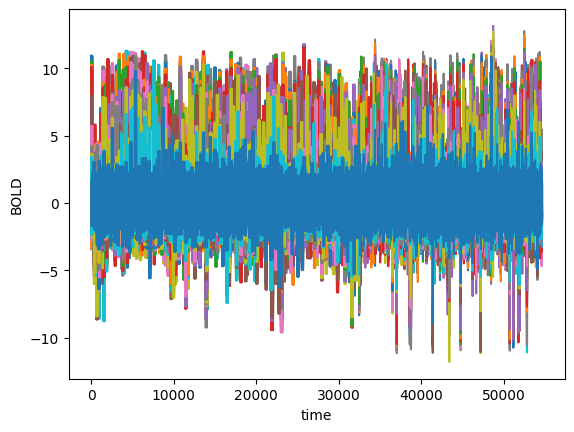

In [ ]:
# EVALUATING PCA
# Concatenate all signals from all subjects along the time axis
concatenated_signals_list = []
avg_activity = []

for sig in collected_signals_sel:
    #sig = np.copy(sig)[5:,:]
    #sig_centered = sig - np.mean(sig)
    #sig_centered = sig_centered - np.mean(sig_centered, axis=1, keepdims=True)
    #concatenated_signals_list.append(sig_centered.T)
    concatenated_signals_list.append(sig.T)
    avg_activity.append(np.mean(sig, axis=0))
    
concatenated_signals = np.concatenate(concatenated_signals_list, axis=1)


TIMES = concatenated_signals.shape[1]
data = np.copy(concatenated_signals) #
#data=values[ch,:].T

mean = np.mean(data, axis=1)
std_data = np.std(data, axis=1)

centered_data = (data - np.tile(mean,(TIMES,1) ).T)/np.tile(std_data,(TIMES,1) ).T

plt.plot(centered_data.T)
plt.xlabel('time')

plt.ylabel('BOLD')


plt.show()

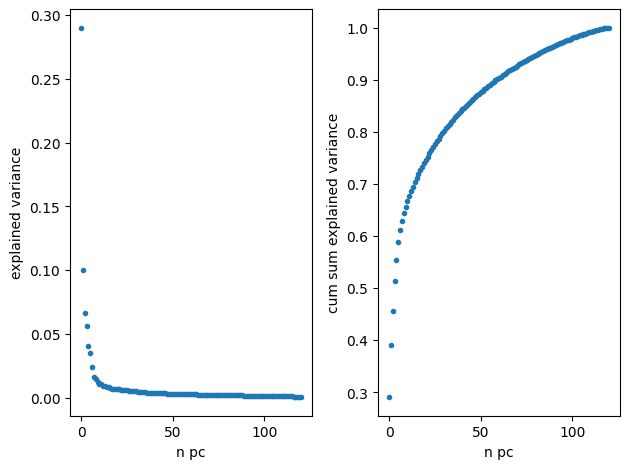

In [15]:
# Step 2: Compute the covariance matrix
covariance_matrix = np.cov(centered_data.T, rowvar=False)

# Step 3: Perform eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

# Step 4: Sort eigenvalues and eigenvectors in descending order

sorted_indices_common = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues_common = eigenvalues[sorted_indices_common]
sorted_eigenvectors_common = eigenvectors[:, sorted_indices_common]

# Step 5: Calculate the principal components
principal_components_common = np.dot(centered_data.T, sorted_eigenvectors_common)

plt.subplot(121)
plt.plot(explained_variance_ratio[sorted_indices_common],'.')
plt.xlabel('n pc')
plt.ylabel('explained variance')

plt.subplot(122)

plt.plot(np.cumsum(explained_variance_ratio[sorted_indices_common]),'.')
plt.xlabel('n pc')
plt.ylabel('cum sum explained variance')

plt.tight_layout()

#concatenated_signals = np.copy(principal_components[:50,:])

N_sites,TIMES = np.shape(concatenated_signals)
trial_duration = TIMES

# Step 2: Compute the covariance matrix
centered_data = np.copy(np.double(concatenated_signals)).T
#covariance_matrix = np.cov( np.double(centered_data) , rowvar=False

dt = 0.005

norm_mua_target_tot = np.copy(centered_data)
norm_mua_target = np.copy(centered_data)


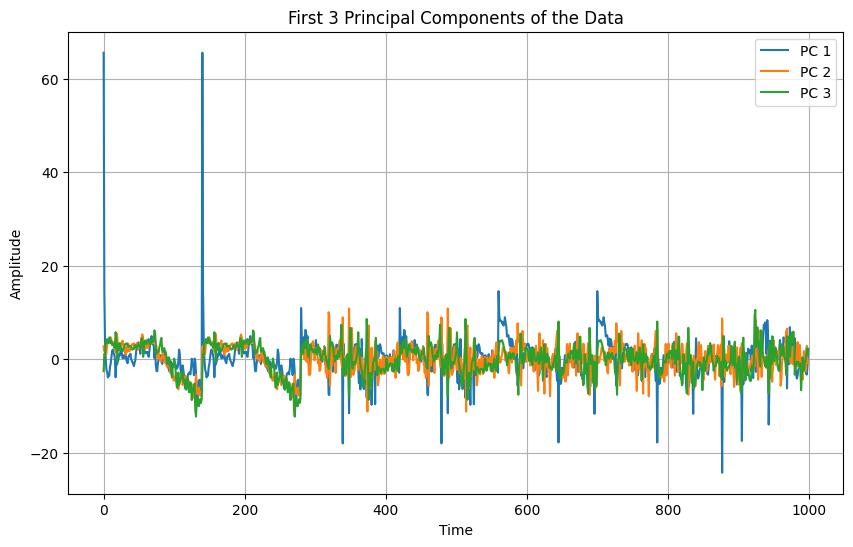

In [16]:
plt.figure(figsize=(10, 6))

# Plot the first 3 principal components
for i in range(3):
    plt.plot(principal_components_common[:1000, i], label=f'PC {i+1}')


plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('First 3 Principal Components of the Data')
plt.legend()
plt.grid(True)
plt.show()

## Optimised functions
The cells below replace `res.RESERVOIRE_SIMPLE` (cells 16–17 in the original notebook)
with versions that:
- **Pre-compute** `decay`/`gain` arrays in `__init__` (avoids `np.exp` inside the hot loop)
- **Skip RNG** in `step_rate` when `sigma_dyn == 0`
- **Remove dead code** (`if_driven` always-true branch, unused list variables)
- **Pre-allocate** NumPy arrays instead of per-step `list.append`
- **Hoist constants** out of inner loops in `train_test`
- **Split driven/autonomous phases** to eliminate the per-step `if_driven` branch


In [17]:
# ── Optimised reservoir class (drop-in replacement for res.RESERVOIRE_SIMPLE) ──
import numpy as np

class RESERVOIRE_SIMPLE:
    """Rate-network reservoir with pre-computed time constants."""

    def __init__(self, par):
        self.N, self.I, self.O, self.T = par['shape']
        self.dt   = par['dt']
        tau_m     = np.linspace(par['tau_m_f'], par['tau_m_s'], self.N)

        # Pre-compute per-unit decay/gain (avoids exp inside the hot loop)
        self.decay = np.exp(-self.dt / tau_m)           # shape (N,)
        self.gain  = 1.0 - self.decay                   # shape (N,)

        self.J    = np.random.normal(0., 1. / np.sqrt(self.N), (self.N, self.N))
        self.Jin  = np.random.normal(0., par['sigma_input'],    (self.N, self.I))
        self.Jout = np.zeros((self.O, self.N))
        self.h_Jout = np.zeros((self.O,))
        self.y    = np.zeros((self.O,))
        self.X    = np.zeros((self.N,))
        self._Xbuf = np.empty((self.N,))   # reusable noise buffer
        self.par  = par

    def step_rate(self, inp, sigma_dyn=0.0):
        if sigma_dyn:
            np.add(self.X, np.random.normal(0., sigma_dyn, self.N), out=self._Xbuf)
            Xd = self._Xbuf
        else:
            Xd = self.X                     # no copy needed; J@Xd is read-only
        self.X = self.decay * self.X + self.gain * (self.J @ Xd + self.Jin @ inp)
        self.y = self.Jout @ self.X + self.h_Jout
        return self.X

    def reset(self, init=None):
        self.X[:] = 0.
        self.y[:] = 0.


In [18]:
def train_test_pinv(feedback_factor=10., sigma_inner_dynamics=0.):
    """Collect driven reservoir activity and target MUA.

    Always runs in driven mode (feedback = norm_mua_target[:, t]).
    Returns arrays of shape (T-1, N) and (T-1, N_sites).
    """
    T      = network_reservoire.T - 1
    N      = network_reservoire.N
    N_out  = network_reservoire.O
    scale  = feedback_factor            # mua_relative_weight

    res_act = np.empty((T, N),     dtype=np.float64)
    mua_act = np.empty((T, N_out), dtype=np.float64)

    network_reservoire.acc = 0

    for t in range(T):
        inp = scale * norm_mua_target[:, t]   # already a new array (scalar * slice)
        network_reservoire.step_rate(inp, sigma_dyn=sigma_inner_dynamics)
        res_act[t] = network_reservoire.X
        mua_act[t] = norm_mua_target[:, t]

    print(res_act.shape, mua_act.shape)
    return res_act, mua_act


In [19]:
def train_test(n_Rep, if_collect=True, sigma_noise_dyn=0,
               sigma_inner_dynamics=0, feedback_factor=10.,
               if_plot_results=False, if_use_reservoir=True,
               perturbation=None):
    """Run n_Rep epochs of driven-then-autonomous simulation.

    Returns (mean_ERROR, mean_ERROR_BEHAVIOR, mean_ERROR_PCA,
             mean_ERROR_BEHAVIOR_NET, mean_ERROR_S_PCA).
    """
    mua_relative_weight = feedback_factor
    add_noise           = sigma_noise_dyn > 0.
    T_run               = trial_duration - 1
    N_out               = network_reservoire.O

    # Constants that do not change across steps/epochs
    driven_steps = min(5, T_run)   # t = 0..5 are driven (if > 0)

    ERROR       = np.empty(n_Rep)
    ERROR_BEH   = np.empty(n_Rep)
    ERROR_PCA   = np.empty(n_Rep)
    ERROR_S_PCA = np.empty(n_Rep)
    ERROR_BEH_NET = np.empty(n_Rep)

    for epoch in range(n_Rep):
        network_reservoire.reset()

        if if_collect:
            INP          = np.empty((T_run, N_out),                dtype=np.float64)
            S_res        = np.empty((T_run, network_reservoire.N), dtype=np.float64)
            S_fromres    = np.empty((T_run, N_out),                dtype=np.float64)
            BEHAVIOR_ACC = np.zeros(T_run,                         dtype=np.float64)
            PCA          = np.empty((T_run, N_out),                dtype=np.float64)

        # ── Phase 1: driven (t = 0 … driven_steps) ─────────────────
        for t in range(driven_steps):
            inp = mua_relative_weight * norm_mua_target[:, t]
            network_reservoire.step_rate(inp, sigma_dyn=sigma_inner_dynamics)
            if add_noise:
                network_reservoire.y += np.random.normal(0, sigma_noise_dyn, N_out)
            if perturbation:
                network_reservoire.y = ((1 - network_reservoire.alpha) * network_reservoire.y
                                        + network_reservoire.alpha
                                        * (network_reservoire.J_targ @ network_reservoire.X))
            if if_collect:
                INP[t]       = inp
                S_res[t]     = network_reservoire.X
                S_fromres[t] = network_reservoire.y
                PCA[t]       = network_reservoire.y

        # ── Phase 2: autonomous (t = driven_steps … T_run) ─────────
        for t in range(driven_steps, T_run):
            inp = mua_relative_weight * network_reservoire.y
            network_reservoire.step_rate(inp, sigma_dyn=sigma_inner_dynamics)
            if add_noise:
                network_reservoire.y += np.random.normal(0, sigma_noise_dyn, N_out)
            if perturbation:
                network_reservoire.y = ((1 - network_reservoire.alpha) * network_reservoire.y
                                        + network_reservoire.alpha
                                        * (network_reservoire.J_targ @ network_reservoire.X))
            if if_collect:
                INP[t]       = inp
                S_res[t]     = network_reservoire.X
                S_fromres[t] = network_reservoire.y
                PCA[t]       = network_reservoire.y

        ERROR[epoch]       = 0.
        ERROR_BEH[epoch]   = 0.
        ERROR_PCA[epoch]   = 0.
        ERROR_S_PCA[epoch] = 0.
        ERROR_BEH_NET[epoch] = 0.

    # ── Optional plot ──────────────────────────────────────────────────────
    if if_plot_results:
        data_target = norm_mua_target.T
        principal_components_data = np.dot(data_target, sorted_eigenvectors_common)

        centered = S_fromres
        principal_components = np.dot(centered, sorted_eigenvectors_common)

        fig, axs = plt.subplots(2, 3, figsize=(10, 5))
        axs[0, 0].imshow(INP[:, :15].T, aspect='auto', cmap='copper',
                         extent=[0, T_run * dt, 0, 15])
        axs[0, 0].set_title('input')
        axs[0, 2].set_title('output')

        for k, ax in enumerate(axs[1]):
            ax.plot(np.arange(len(principal_components_data)) * dt,
                    principal_components_data[:, k], label='data')
            ax.plot(np.arange(len(principal_components)) * dt,
                    principal_components[:, k], label='model')
            ax.set_xlabel('time (s)')
            ax.set_ylabel(f'PC {k + 1}')
            ax.legend()

        plt.tight_layout()
        plt.savefig('fig.eps')
        plt.savefig('fig.png')
        plt.show()

    # ── Store results on network object ──────────────────────────────────
    if if_use_reservoir:
        data = S_fromres
    else:
        data = S_fromres   # fallback (S was unused in original)

    principal_components      = np.dot(data, sorted_eigenvectors_common)
    principal_components_data = np.dot(norm_mua_target.T, sorted_eigenvectors_common)

    network_reservoire.data                      = data
    network_reservoire.principal_components      = principal_components
    network_reservoire.principal_components_data = principal_components_data

    return (np.mean(ERROR), np.mean(ERROR_BEH), np.mean(ERROR_PCA),
            np.mean(ERROR_BEH_NET), np.mean(ERROR_S_PCA))


In [20]:
spectral_radius = .95

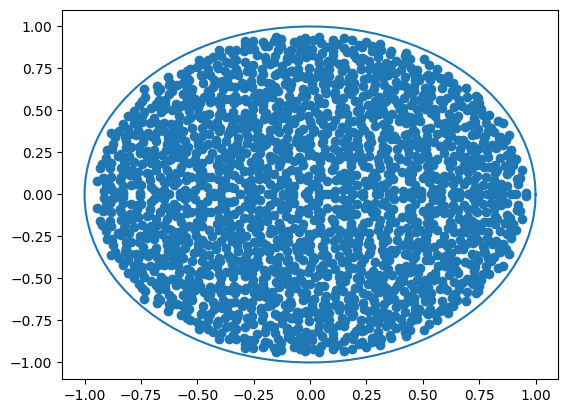

In [21]:
import gym
import numpy as np
from copy import deepcopy
from tqdm import trange
from matplotlib import pyplot as plt
from matplotlib.animation import ArtistAnimation
from gym.envs.mujoco import AntEnv  # Assuming you're using MuJoCo's Ant environment


from scipy.stats import pearsonr
import pickle

#network_reservoire.J = (network_reservoire.J + network_reservoire.J.T)/2./np.sqrt(2.)

if_save_res = True
if_load_res = False
N_PC = 20 # Number of principal components to use
N_sites = 121 # Number of sites in the Schaefer atlas

trial_duration = 139

N, I, O, TIME = 2000, N_sites, N_sites , 600
shape = (N, I, O, TIME)

dt = .005# / T;

tau_m_f = .0001 * dt
tau_m_s = .0001 * dt
sigma_input = .01

n_electrodes = N_sites
n_pca = n_electrodes

# Here we build the dictionary of the simulation parameters
par = {'tau_m_f' : tau_m_f,'tau_m_s' : tau_m_s,
    'N' : N, 'T' : TIME, 'dt' : dt,
    'sigma_input' : sigma_input, 'shape' : shape}
n_pca_feedback = N_sites#3#only

shape = ( N , n_pca_feedback, N_sites, TIME)
par['shape']=shape

network_reservoire = RESERVOIRE_SIMPLE(par)

if if_save_res:
    with open('network_reservoire.pkl', 'wb') as f:
        pickle.dump(network_reservoire, f)

if if_load_res:
    with open('network_reservoire.pkl', 'rb') as f:
        network_reservoire = pickle.load(f)

network_reservoire.J = network_reservoire.J * spectral_radius

eigenvalues, eigenvectors = np.linalg.eig(network_reservoire.J)

real_parts = np.real(eigenvalues)
imaginary_parts = np.imag(eigenvalues)

# Create a scatter plot
plt.scatter(real_parts, imaginary_parts)

theta = np.linspace(0, 2 * np.pi, 100)

# Circle center coordinates
center = (0, 0)
# Circle radius
radius = 1.

# Calculate circle points
x = center[0] + radius * np.cos(theta)
y = center[1] + radius * np.sin(theta)

# Plot the circle
plt.plot(x, y)

err_collected = []


In [22]:
len(concatenated_signals_list)

378

In [23]:
# Initialize storage for fitted weights
fitted_weights = {}

trial_duration = 139

fitted_weights_list = []
FC_SIM_COLLECTED = []
X_coll = []
Y_coll = []

means = []

all_weights = []

detrended_means = []
FC_degree_collected = []

FC_plus_collected_sel = []
FC_plus_collected_sel_sim = []

FC_collected = []

Y_coll_sim = []
ccs_orig = []

# Perform 10 trials per dataset
for patient in trange(len(concatenated_signals_list)):

    data = np.copy(concatenated_signals_list[patient]) # Use the first run of the patient data
    #data = data - np.mean(data, axis=1, keepdims=True) 
    network_reservoire.T = np.shape(data)[1]  # Set the trial duration based on the data shape
    network_reservoire.reset()  # Reset the reservoir network for each patient

    #norm_mua_target = np.copy(data)
    # Remove PC1 as detrending
    u, s, vt = np.linalg.svd(data - np.mean(data, axis=1, keepdims=True), full_matrices=False)
    pc1 = np.outer(u[:, 0], s[0] * vt[0, :])
    norm_mua_target = np.copy(data)# - pc1)
    # Project onto first 5 principal components only
    #norm_mua_target = np.dot(norm_mua_target.T, sorted_eigenvectors[:, :N_PC]).T
    detrended_means.append(np.mean(norm_mua_target, axis=1, keepdims=True))

    eigenvectors_5 = sorted_eigenvectors_common[:, 0:50]
    
    # Step 1: project onto the first 5 PCs
    pc_5_scores = np.dot(data.T, eigenvectors_5)
    # Step 2: reconstruct (reproject back)
    norm_mua_target = np.dot(pc_5_scores, eigenvectors_5.T).T

    # Z-score normalization
    #norm_mua_target = (norm_mua_target - np.mean(norm_mua_target, axis=1, keepdims=True)) / np.std(norm_mua_target, axis=1, keepdims=True)
    #norm_mua_target = (norm_mua_target - np.mean(norm_mua_target, axis=1, keepdims=True)) / np.std(norm_mua_target, axis=1, keepdims=True)
    fc_matrix = np.corrcoef(norm_mua_target)
    fc_matrix = np.nan_to_num(fc_matrix)   
    FC_collected.append(fc_matrix.flatten())
    FC_degree_collected.append(np.sum(np.corrcoef(norm_mua_target),axis=1))

    fc_matrix_delayed = np.corrcoef(norm_mua_target.T[:-1,:].T, norm_mua_target.T[1:,:].T)
    fc_matrix_delayed = np.nan_to_num(fc_matrix_delayed)
    fc_delayed_flat = fc_matrix_delayed[121:,:121]

    # Concatenate both flattened arrays
    fc_features = np.concatenate([fc_matrix.flatten(), fc_delayed_flat.flatten()])

    #print(np.shape(fc_features))

    FC_plus_collected_sel.append(fc_features)
    
    means.append(np.mean(data, axis=1, keepdims=True))
    weights_list = []
    

    X, Y = train_test_pinv(feedback_factor=recurrent_factor)

    X = np.array(X)[10:,:]
    Y = np.array(Y)[10:,:]
    
    Y_coll.append(Y)
    X_coll.append(X)
    weights_list_mean=[]
    
    noise_size = .025*.5*.5
        
    W_out = np.linalg.pinv(X + np.random.normal(0, noise_size, size=np.shape(X))).dot(Y)
    mse = np.mean((Y - np.dot(X, W_out))**2)
    print(mse)

    weights_list.append(W_out)
    all_weights.append(W_out.flatten())
    fitted_weights[patient] = weights_list
    fitted_weights_list.append(W_out)
    network_reservoire.Jout = np.copy(W_out.T)
    err,err_out,err_pca,_,err_spca = train_test(1,sigma_noise_dyn=.0,feedback_factor=recurrent_factor,if_plot_results=False)

    fc_sim_data = np.corrcoef(network_reservoire.data.T)
    fc_sim_data = np.nan_to_num(fc_sim_data)
    FC_SIM_COLLECTED.append(fc_sim_data.flatten())

    fc_matrix_delayed_sim = np.corrcoef(network_reservoire.data[:-1,:].T, network_reservoire.data[1:,:].T)
    fc_matrix_delayed_sim = np.nan_to_num(fc_matrix_delayed_sim)
    fc_delayed_flat = fc_matrix_delayed_sim[121:,:121]

    # Concatenate both flattened arrays
    fc_features = np.concatenate([fc_sim_data.flatten(), fc_delayed_flat.flatten()])

    FC_plus_collected_sel_sim.append(fc_features)

    print(np.corrcoef(FC_SIM_COLLECTED[-1],FC_collected[-1])[0,1])
    ccs_orig.append(np.corrcoef(FC_SIM_COLLECTED[-1],FC_collected[-1])[0,1])

    
    


  0%|          | 1/378 [00:00<01:29,  4.22it/s]

(139, 2000) (139, 121)
0.005365207561458783
0.8922262691970372


  1%|          | 2/378 [00:00<01:23,  4.48it/s]

(139, 2000) (139, 121)
0.005326806294727074
0.8408920394098665


  1%|          | 3/378 [00:00<01:14,  5.06it/s]

...

0.8694412236211841
(139, 2000) (139, 121)
0.00444013764151498


100%|█████████▉| 377/378 [01:20<00:00,  4.28it/s]

0.8427251006629431
(139, 2000) (139, 121)
0.00459068714852236


100%|██████████| 378/378 [01:21<00:00,  4.66it/s]

0.9408588148256063


Scanning K_PC...


100%|██████████| 6/6 [00:55<00:00,  9.21s/it]



Auto-selected K_PC = 200  (projection cost = -1.11e-18  vs threshold 4.74e-05)


Projecting with K_PC_auto: 100%|██████████| 378/378 [00:09<00:00, 41.42it/s]



Scanning M (number of archetypes)...


100%|██████████| 7/7 [00:22<00:00,  3.15s/it]


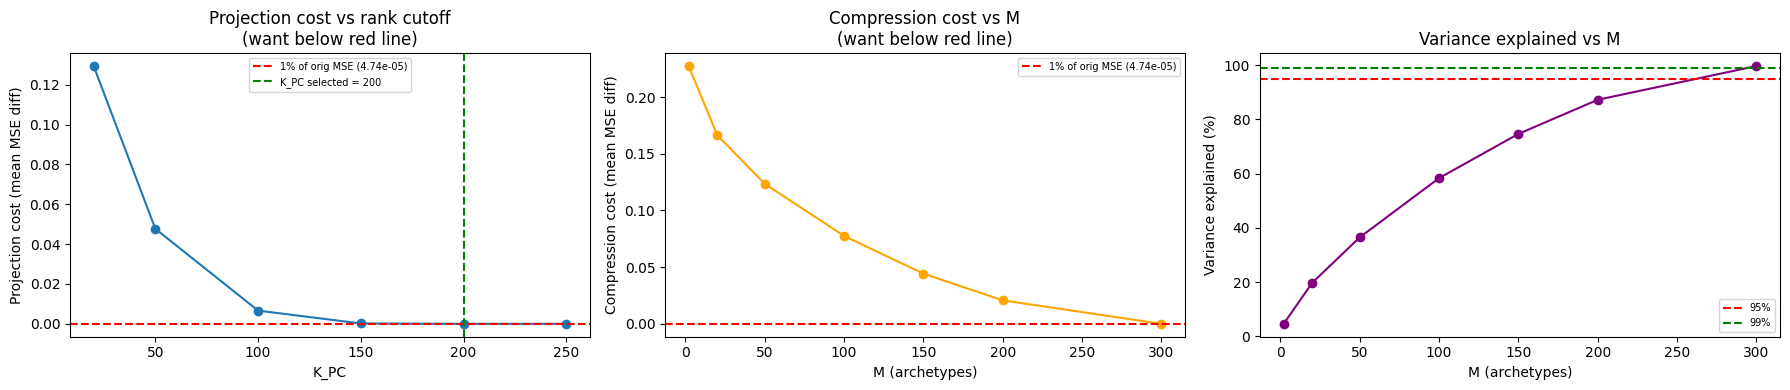


Summary:
  Original MSE:    0.0047
  Projected MSE:   0.0047  (cost: -1.11e-18)
  M=  2:  compression cost=2.27e-01  var_exp=4.6%
  M= 20:  compression cost=1.66e-01  var_exp=19.8%
  M= 50:  compression cost=1.23e-01  var_exp=36.5%
  M=100:  compression cost=7.74e-02  var_exp=58.4%
  M=150:  compression cost=4.41e-02  var_exp=74.7%
  M=200:  compression cost=2.06e-02  var_exp=87.2%
  M=300:  compression cost=-1.58e-04  var_exp=99.7%


In [24]:
if_explore_parameters = True
if if_explore_parameters:

    import numpy as np
    import torch
    import matplotlib.pyplot as plt
    from tqdm import tqdm

    all_ids = list(range(len(X_coll)))

    # ============================================================
    # Scan 1 — find the right K_PC by checking projection cost
    #          as a function of rank cutoff
    # ============================================================

    K_candidates = [20, 50, 100, 150, 200, 250 ]

    mse_original = []
    for pid in all_ids:
        X   = np.array(X_coll[pid],              dtype=np.float64)
        Y   = np.array(Y_coll[pid],              dtype=np.float64)
        W_i = np.array(fitted_weights_list[pid], dtype=np.float64).T
        mse_original.append(np.mean((Y - X @ W_i.T) ** 2))
    mse_original = np.array(mse_original)

    proj_costs = []   # mean(mse_proj - mse_orig) for each K

    print("Scanning K_PC...")
    for K in tqdm(K_candidates):
        mse_proj_k = []
        for pid in all_ids:
            X   = np.array(X_coll[pid],              dtype=np.float64)
            Y   = np.array(Y_coll[pid],              dtype=np.float64)
            W_i = np.array(fitted_weights_list[pid], dtype=np.float64).T

            _, s, Vt = np.linalg.svd(X, full_matrices=False)
            k        = min(K, np.sum(s > 1e-8))
            Vt_k     = Vt[:k]
            W_proj   = W_i @ Vt_k.T @ Vt_k
            mse_proj_k.append(np.mean((Y - X @ W_proj.T) ** 2))

        proj_costs.append(np.mean(np.array(mse_proj_k) - mse_original))

    # ============================================================
    # Scan 2 — find the right M by checking compression cost
    #          for the best K_PC found above
    # ============================================================

    # Pick K_PC where projection cost has saturated (< 1% of original)
    threshold_proj = 0.01 * mse_original.mean()
    K_PC_auto = K_candidates[next(
        (i for i, c in enumerate(proj_costs) if c < threshold_proj),
        -1   # fallback to largest if none found
    )]
    print(f"\nAuto-selected K_PC = {K_PC_auto}  "
        f"(projection cost = {proj_costs[K_candidates.index(K_PC_auto)]:.2e}  "
        f"vs threshold {threshold_proj:.2e})")

    # Recompute projections with K_PC_auto
    W_proj_list, Vt_list = [], []
    for pid in tqdm(all_ids, desc="Projecting with K_PC_auto"):
        X   = np.array(X_coll[pid],              dtype=np.float64)
        W_i = np.array(fitted_weights_list[pid], dtype=np.float64).T
        _, s, Vt = np.linalg.svd(X, full_matrices=False)
        k        = min(K_PC_auto, np.sum(s > 1e-8))
        Vt_k     = Vt[:k]
        W_proj_list.append((W_i @ Vt_k.T @ Vt_k).flatten())
        Vt_list.append(Vt_k)

    W_stack    = np.stack(W_proj_list)
    W_mean     = W_stack.mean(axis=0, keepdims=True)
    W_centered = W_stack - W_mean
    U_s, S_s, Vt_s = np.linalg.svd(W_centered, full_matrices=False)

    M_candidates  = [2, 20, 50, 100, 150, 200, 300 ]
    comp_costs    = []
    var_exp_curve = []

    N_out = np.array(fitted_weights_list[0]).shape[1]
    N_in  = np.array(fitted_weights_list[0]).shape[0]

    mse_projected = []
    for idx, pid in enumerate(all_ids):
        X     = np.array(X_coll[pid], dtype=np.float64)
        Y     = np.array(Y_coll[pid], dtype=np.float64)
        W_proj = W_proj_list[idx].reshape(N_out, N_in)
        mse_projected.append(np.mean((Y - X @ W_proj.T) ** 2))
    mse_projected = np.array(mse_projected)

    print("\nScanning M (number of archetypes)...")
    for M in tqdm(M_candidates):
        archetypes = Vt_s[:M]
        G_scores   = U_s[:, :M] * S_s[:M]
        W_mean_t   = torch.tensor(W_mean.reshape(N_out, N_in), dtype=torch.float32)
        W_fixed    = torch.tensor(archetypes.reshape(M, N_out, N_in), dtype=torch.float32)

        mse_arch_m = []
        for idx, pid in enumerate(all_ids):
            X   = torch.tensor(X_coll[pid], dtype=torch.float32)
            Y   = torch.tensor(Y_coll[pid], dtype=torch.float32)
            g   = torch.tensor(G_scores[idx], dtype=torch.float32)
            W_g = (g[:, None, None] * W_fixed).sum(0) + W_mean_t
            mse_arch_m.append(((Y - X @ W_g.T) ** 2).mean().item())

        comp_costs.append(np.mean(np.array(mse_arch_m) - mse_projected))
        var_exp_curve.append((S_s[:M] ** 2).sum() / (S_s ** 2).sum())

    # ============================================================
    # Plots
    # ============================================================

    fig, ax = plt.subplots(1, 3, figsize=(18, 4))

    # Panel 0 — projection cost vs K_PC
    ax[0].plot(K_candidates, proj_costs, '-o')
    ax[0].axhline(threshold_proj, color='red', linestyle='--',
                label=f'1% of orig MSE ({threshold_proj:.2e})')
    ax[0].axvline(K_PC_auto, color='green', linestyle='--',
                label=f'K_PC selected = {K_PC_auto}')
    ax[0].set_xlabel("K_PC"); ax[0].set_ylabel("Projection cost (mean MSE diff)")
    ax[0].set_title("Projection cost vs rank cutoff\n(want below red line)")
    ax[0].legend(fontsize=7)

    # Panel 1 — compression cost vs M
    ax[1].plot(M_candidates, comp_costs, '-o', color='orange')
    ax[1].axhline(threshold_proj, color='red', linestyle='--',
                label=f'1% of orig MSE ({threshold_proj:.2e})')
    ax[1].set_xlabel("M (archetypes)"); ax[1].set_ylabel("Compression cost (mean MSE diff)")
    ax[1].set_title("Compression cost vs M\n(want below red line)")
    ax[1].legend(fontsize=7)

    # Panel 2 — variance explained vs M
    ax[2].plot(M_candidates, np.array(var_exp_curve) * 100, '-o', color='purple')
    ax[2].axhline(95, color='red', linestyle='--', label='95%')
    ax[2].axhline(99, color='green', linestyle='--', label='99%')
    ax[2].set_xlabel("M (archetypes)"); ax[2].set_ylabel("Variance explained (%)")
    ax[2].set_title("Variance explained vs M")
    ax[2].legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    print(f"\nSummary:")
    print(f"  Original MSE:    {mse_original.mean():.4f}")
    print(f"  Projected MSE:   {mse_projected.mean():.4f}  "
        f"(cost: {(mse_projected-mse_original).mean():.2e})")
    for M, cc, ve in zip(M_candidates, comp_costs, var_exp_curve):
        print(f"  M={M:3d}:  compression cost={cc:.2e}  var_exp={ve*100:.1f}%")

(array([ 3.,  2.,  5., 11., 17., 39., 69., 62., 85., 85.]),
 array([0.37374218, 0.43413319, 0.4945242 , 0.55491521, 0.61530621,
        0.67569722, 0.73608823, 0.79647924, 0.85687025, 0.91726126,
        0.97765227]),
 <BarContainer object of 10 artists>)

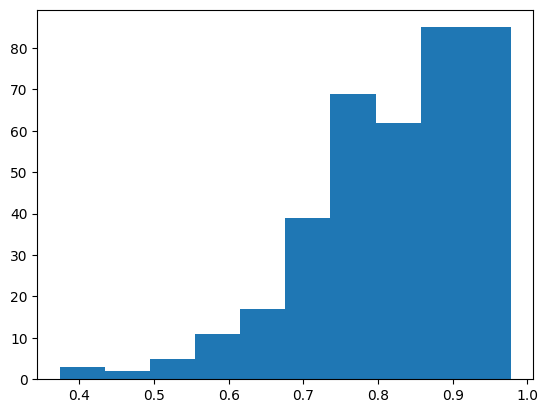

In [25]:
plt.hist(ccs_orig)

Step 1 — projecting W_i onto row space of X_i...


100%|██████████| 378/378 [00:10<00:00, 35.60it/s]



Step 3 — computing archetype MSE in Y space...


100%|██████████| 378/378 [00:07<00:00, 47.58it/s]



MSE original   (W_i @ X vs Y)          — mean: 0.0047  std: 0.0004
MSE projected  (W_proj @ X vs Y)        — mean: 0.0049  std: 0.0010
MSE archetype  (W_g @ X vs Y, M=290)    — mean: 0.0047  std: 0.0010

Projection cost (proj - orig):           mean: 1.75e-04
Compression cost (arch - proj):           mean: -1.84e-04
Total cost (arch - orig):                 mean: -9.59e-06


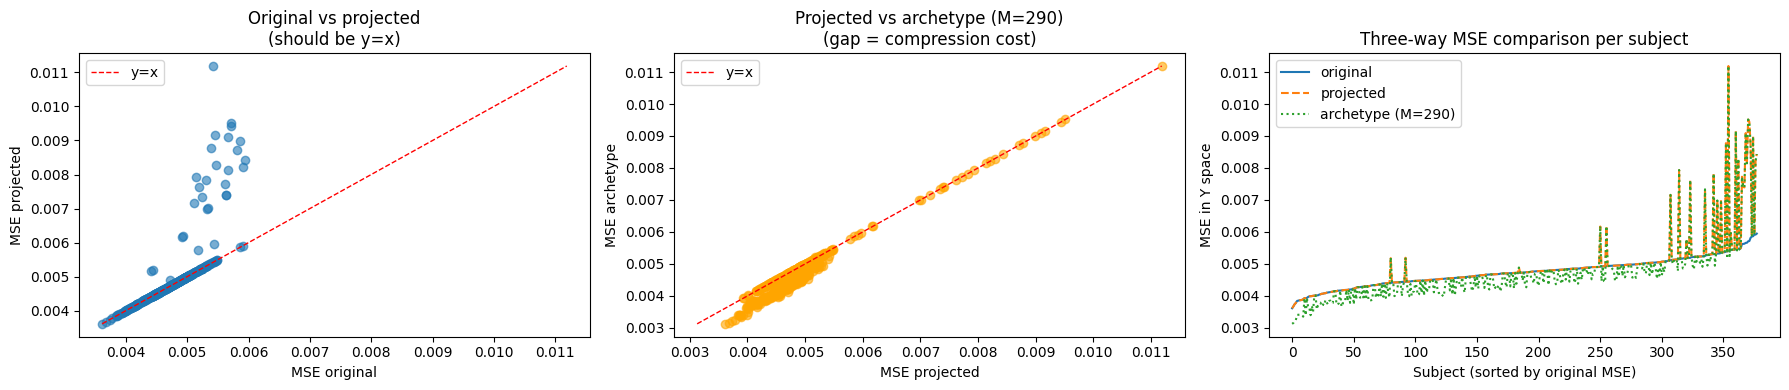

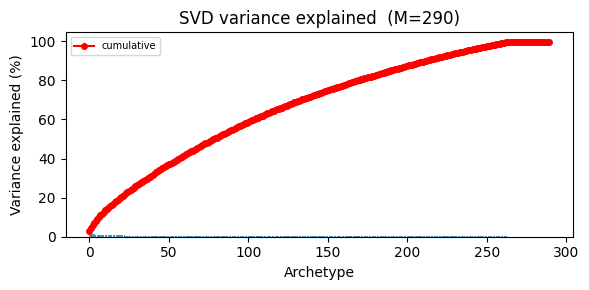

In [26]:
import numpy as np
import torch
import torch.linalg as LA
import matplotlib.pyplot as plt
from tqdm import tqdm

K_PC    = 150
M       = 290
all_ids = list(range(len(X_coll)))

W_proj_list = []
Vt_list     = []

mse_original  = []
mse_projected = []

print("Step 1 — projecting W_i onto row space of X_i...")
for idx, pid in enumerate(tqdm(all_ids)):
    X   = np.array(X_coll[pid],              dtype=np.float64)
    Y   = np.array(Y_coll[pid],              dtype=np.float64)
    W_i = np.array(fitted_weights_list[pid], dtype=np.float64).T  # [N_out, N_in]

    _, s, Vt = np.linalg.svd(X, full_matrices=False)
    k        = min(K_PC, np.sum(s > 1e-8))
    Vt_k     = Vt[:k]

    W_proj = W_i @ Vt_k.T @ Vt_k          # [N_out, N_in]

    Y_orig = X @ W_i.T
    Y_proj = X @ W_proj.T

    mse_original.append( np.mean((Y - Y_orig) ** 2))
    mse_projected.append(np.mean((Y - Y_proj) ** 2))

    W_proj_list.append(W_proj.flatten())
    Vt_list.append(Vt_k)

mse_original  = np.array(mse_original)
mse_projected = np.array(mse_projected)

# ============================================================
# Step 2 — SVD of projected weights → archetypes + G scores
# ============================================================

W_stack    = np.stack(W_proj_list)
W_mean     = W_stack.mean(axis=0, keepdims=True)
W_centered = W_stack - W_mean

U_s, S_s, Vt_s = np.linalg.svd(W_centered, full_matrices=False)

archetypes = Vt_s[:M]               # [M, N_out*N_in]
G_scores   = U_s[:, :M] * S_s[:M]  # [P, M]

var_explained = (S_s[:M] ** 2) / (S_s ** 2).sum()

W_out_shape = (np.array(fitted_weights_list[0]).shape[1],   # N_out
               np.array(fitted_weights_list[0]).shape[0])   # N_in
N_out, N_in = W_out_shape

W_fixed  = torch.tensor(archetypes.reshape(M, N_out, N_in), dtype=torch.float32)
W_mean_t = torch.tensor(W_mean.reshape(N_out, N_in),        dtype=torch.float32)

# ============================================================
# Step 3 — Compute all three MSEs per subject
# ============================================================

mse_archetype = []

print("\nStep 3 — computing archetype MSE in Y space...")
for idx, pid in enumerate(tqdm(all_ids)):
    X   = torch.tensor(X_coll[pid],              dtype=torch.float32)
    Y   = torch.tensor(Y_coll[pid],              dtype=torch.float32)

    g   = torch.tensor(G_scores[idx],            dtype=torch.float32)   # [M]
    W_g = (g[:, None, None] * W_fixed).sum(0) + W_mean_t               # [N_out, N_in]

    Y_hat = X @ W_g.T                                                   # [T, N_out]
    mse_archetype.append(((Y - Y_hat) ** 2).mean().item())

mse_archetype = np.array(mse_archetype)

# ============================================================
# Summary
# ============================================================

print(f"\nMSE original   (W_i @ X vs Y)          — mean: {mse_original.mean():.4f}  std: {mse_original.std():.4f}")
print(f"MSE projected  (W_proj @ X vs Y)        — mean: {mse_projected.mean():.4f}  std: {mse_projected.std():.4f}")
print(f"MSE archetype  (W_g @ X vs Y, M={M})    — mean: {mse_archetype.mean():.4f}  std: {mse_archetype.std():.4f}")
print(f"\nProjection cost (proj - orig):           mean: {(mse_projected - mse_original).mean():.2e}")
print(f"Compression cost (arch - proj):           mean: {(mse_archetype - mse_projected).mean():.2e}")
print(f"Total cost (arch - orig):                 mean: {(mse_archetype - mse_original).mean():.2e}")

# ============================================================
# Plots
# ============================================================

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

# Panel 0 — scatter: original vs projected (should be y=x)
ax[0].scatter(mse_original, mse_projected, alpha=0.6)
lims = [min(mse_original.min(), mse_projected.min()),
        max(mse_original.max(), mse_projected.max())]
ax[0].plot(lims, lims, 'r--', linewidth=1, label='y=x')
ax[0].set_xlabel("MSE original"); ax[0].set_ylabel("MSE projected")
ax[0].set_title("Original vs projected\n(should be y=x)")
ax[0].legend()

# Panel 1 — scatter: projected vs archetype (compression cost)
ax[1].scatter(mse_projected, mse_archetype, alpha=0.6, color='orange')
lims = [min(mse_projected.min(), mse_archetype.min()),
        max(mse_projected.max(), mse_archetype.max())]
ax[1].plot(lims, lims, 'r--', linewidth=1, label='y=x')
ax[1].set_xlabel("MSE projected"); ax[1].set_ylabel("MSE archetype")
ax[1].set_title(f"Projected vs archetype (M={M})\n(gap = compression cost)")
ax[1].legend()

# Panel 2 — all three per subject sorted by original MSE
sort_idx = np.argsort(mse_original)
x        = np.arange(len(all_ids))
ax[2].plot(x, mse_original[sort_idx],  '-',  label='original',  linewidth=1.5)
ax[2].plot(x, mse_projected[sort_idx], '--', label='projected',  linewidth=1.5)
ax[2].plot(x, mse_archetype[sort_idx], ':',  label=f'archetype (M={M})', linewidth=1.5)
ax[2].set_xlabel("Subject (sorted by original MSE)")
ax[2].set_ylabel("MSE in Y space")
ax[2].set_title("Three-way MSE comparison per subject")
ax[2].legend()

plt.tight_layout()
plt.show()

# Bonus — variance explained curve (how many archetypes are enough?)
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(M), var_explained * 100, alpha=0.8)
ax.plot(range(M), np.cumsum(var_explained) * 100,
        '-o', color='red', markersize=4, label='cumulative')
ax.set_xlabel("Archetype"); ax.set_ylabel("Variance explained (%)")
ax.set_title(f"SVD variance explained  (M={M})")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [27]:
# Initialize storage

ccs_reduced = []

fitted_weights = {}
trial_duration = 139
fitted_weights_list = []
FC_SIM_COLLECTED = []
X_coll = []
Y_coll = []
means = []
all_weights = []
detrended_means = []
FC_degree_collected = []
FC_plus_collected_sel = []
FC_plus_collected_sel_sim = []
FC_collected = []
Y_coll_sim = []

# W_fixed   [M, N_out, N_in]  — archetypes from SVD
# W_mean_t  [N_out, N_in]     — population mean weight
# G_scores  [P, M]            — per-subject mixing coordinates

W_mean_t = torch.tensor(W_mean.reshape(N_out, N_in), dtype=torch.float32)

for patient in range(len(concatenated_signals_list)):

    data = np.copy(concatenated_signals_list[patient])
    network_reservoire.T = np.shape(data)[1]
    network_reservoire.reset()

    u, s, vt = np.linalg.svd(data - np.mean(data, axis=1, keepdims=True), full_matrices=False)
    norm_mua_target = np.copy(data)
    detrended_means.append(np.mean(norm_mua_target, axis=1, keepdims=True))

    eigenvectors_5   = sorted_eigenvectors_common[:, 0:50]
    pc_5_scores      = np.dot(data.T, eigenvectors_5)
    norm_mua_target  = np.dot(pc_5_scores, eigenvectors_5.T).T

    fc_matrix = np.nan_to_num(np.corrcoef(norm_mua_target))
    FC_collected.append(fc_matrix.flatten())
    FC_degree_collected.append(np.sum(fc_matrix, axis=1))

    fc_matrix_delayed = np.nan_to_num(
        np.corrcoef(norm_mua_target.T[:-1, :].T, norm_mua_target.T[1:, :].T))
    fc_delayed_flat   = fc_matrix_delayed[121:, :121]
    fc_features       = np.concatenate([fc_matrix.flatten(), fc_delayed_flat.flatten()])
    print(np.shape(fc_features))
    FC_plus_collected_sel.append(fc_features)

    means.append(np.mean(data, axis=1, keepdims=True))

    X, Y = train_test_pinv(feedback_factor=recurrent_factor)
    X = np.array(X)[10:, :]
    Y = np.array(Y)[10:, :]
    X_coll.append(X)
    Y_coll.append(Y)

    # ── Archetype reconstruction ──────────────────────────────
    g_i = torch.tensor(G_scores[patient], dtype=torch.float32)      # [M]
    W_i = (g_i[:, None, None] * W_fixed).sum(0) + W_mean_t          # [N_out, N_in]
    W_out = W_i.T.detach().cpu().numpy()                             # [N_in, N_out]
    # ─────────────────────────────────────────────────────────

    network_reservoire.Jout = np.copy(W_out.T)
    err, err_out, err_pca, _, err_spca = train_test(
        1, sigma_noise_dyn=0.0,
        feedback_factor=recurrent_factor,
        if_plot_results=False,
    )

    fc_sim_data = np.nan_to_num(np.corrcoef(network_reservoire.data.T))
    FC_SIM_COLLECTED.append(fc_sim_data.flatten())
    Y_coll_sim.append(network_reservoire.data.T)

    fc_matrix_delayed_sim = np.nan_to_num(
        np.corrcoef(network_reservoire.data[:-1, :].T,
                    network_reservoire.data[1:,  :].T))
    fc_delayed_flat_sim   = fc_matrix_delayed_sim[121:, :121]
    fc_features_sim       = np.concatenate([fc_sim_data.flatten(),
                                            fc_delayed_flat_sim.flatten()])
    FC_plus_collected_sel_sim.append(fc_features_sim)

    fitted_weights_list.append(W_out)
    fitted_weights[patient] = W_out

    r = np.corrcoef(FC_SIM_COLLECTED[-1], FC_collected[-1])[0, 1]
    print(f"patient {patient:3d}  FC correlation: {r:.3f}")
    ccs_reduced.append(r)

(29282,)
(139, 2000) (139, 121)
patient   0  FC correlation: 0.840
(29282,)
(139, 2000) (139, 121)
patient   1  FC correlation: 0.797
(29282,)
(139, 2000) (139, 121)
patient   2  FC correlation: 0.800
(29282,)
(139, 2000) (139, 121)
patient   3  FC correlation: 0.805
(29282,)
(139, 2000) (139, 121)
patient   4  FC correlation: 0.901
(29282,)
(139, 2000) (139, 121)
patient   5  FC correlation: 0.924
(29282,)
(139, 2000) (139, 121)
patient   6  FC correlation: 0.795
(29282,)
(139, 2000) (139, 121)
patient   7  FC correlation: 0.798
(29282,)
(139, 2000) (139, 121)
patient   8  FC correlation: 0.793
(29282,)
(139, 2000) (139, 121)
patient   9  FC correlation: 0.862
(29282,)
(139, 2000) (139, 121)
patient  10  FC correlation: 0.886
(29282,)
(139, 2000) (139, 121)
patient  11  FC correlation: 0.927
(29282,)
(139, 2000) (139, 121)
patient  12  FC correlation: 0.774
(29282,)
(139, 2000) (139, 121)
patient  13  FC correlation: 0.855
(29282,)
(139, 2000) (139, 121)
patient  14  FC correlation: 0

Original  — mean: 0.820  median: 0.840  std: 0.111
Reduced   — mean: 0.820  median: 0.842  std: 0.111
Difference (reduced - original) — mean: 0.000  std: 0.021
Wilcoxon signed-rank test: stat=35341.000  p=0.8234


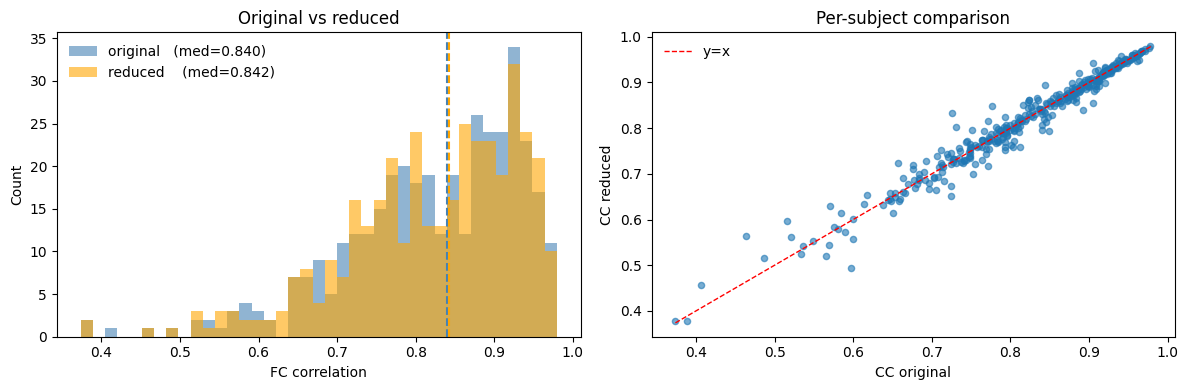

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# ── Panel 0: overlapping histograms ──────────────────────────
bins = np.linspace(
    min(np.min(ccs_orig), np.min(ccs_reduced)),
    max(np.max(ccs_orig), np.max(ccs_reduced)),
    40
)

ax[0].hist(ccs_orig,    bins=bins, alpha=0.6, color='steelblue',
           label=f'original   (med={np.median(ccs_orig):.3f})')
ax[0].hist(ccs_reduced, bins=bins, alpha=0.6, color='orange',
           label=f'reduced    (med={np.median(ccs_reduced):.3f})')
ax[0].axvline(np.median(ccs_orig),    color='steelblue', linestyle='--', linewidth=1.5)
ax[0].axvline(np.median(ccs_reduced), color='orange',    linestyle='--', linewidth=1.5)
ax[0].set_xlabel("FC correlation"); ax[0].set_ylabel("Count")
ax[0].set_title("Original vs reduced")
ax[0].legend(frameon=False)

# ── Panel 1: scatter original vs reduced (one dot per subject) ─
ax[1].scatter(ccs_orig, ccs_reduced, alpha=0.6, s=20)
lims = [min(np.min(ccs_orig), np.min(ccs_reduced)),
        max(np.max(ccs_orig), np.max(ccs_reduced))]
ax[1].plot(lims, lims, 'r--', linewidth=1, label='y=x')
ax[1].set_xlabel("CC original"); ax[1].set_ylabel("CC reduced")
ax[1].set_title("Per-subject comparison")
ax[1].legend(frameon=False)

# ── Stats ─────────────────────────────────────────────────────
t_stat, p_val = stats.wilcoxon(ccs_orig, ccs_reduced)
diff = np.array(ccs_reduced) - np.array(ccs_orig)
print(f"Original  — mean: {np.mean(ccs_orig):.3f}  median: {np.median(ccs_orig):.3f}  std: {np.std(ccs_orig):.3f}")
print(f"Reduced   — mean: {np.mean(ccs_reduced):.3f}  median: {np.median(ccs_reduced):.3f}  std: {np.std(ccs_reduced):.3f}")
print(f"Difference (reduced - original) — mean: {diff.mean():.3f}  std: {diff.std():.3f}")
print(f"Wilcoxon signed-rank test: stat={t_stat:.3f}  p={p_val:.4f}")

plt.tight_layout()
plt.show()

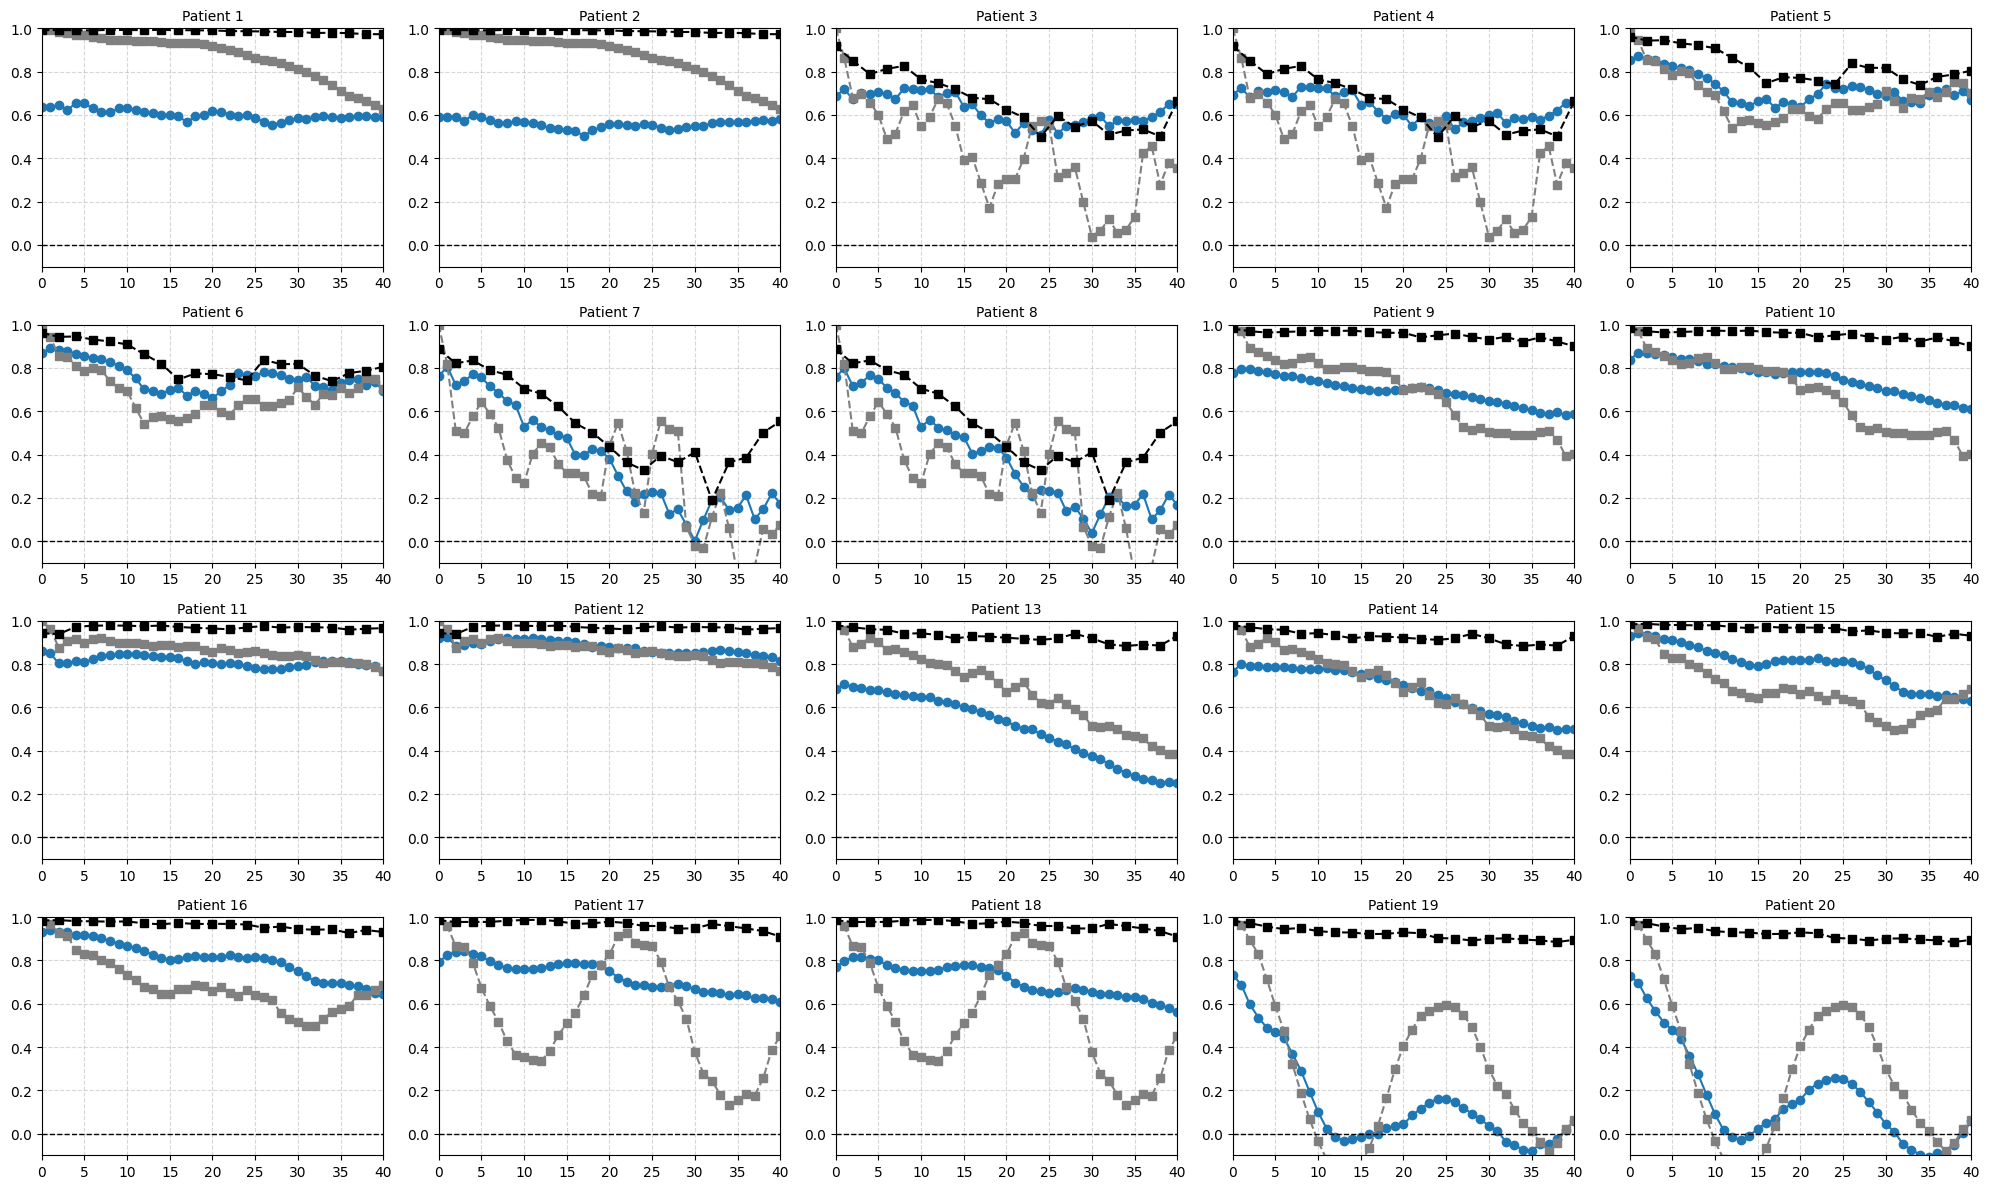

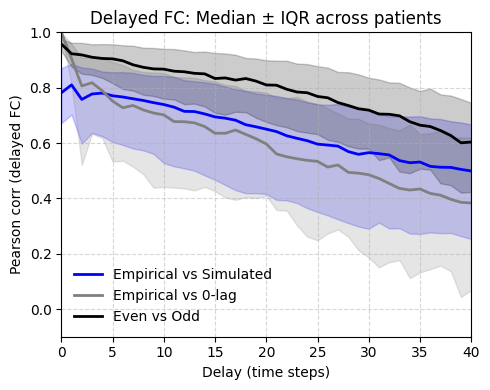

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def compute_delayed_fc(data, delay):
    """Return delayed FC matrix for a given delay (data shape: regions x time)."""
    if delay < 0:
        raise ValueError("delay must be >= 0")
    if delay == 0:
        return np.nan_to_num(np.corrcoef(data))
    if data.shape[1] <= delay:
        raise ValueError("delay must be smaller than the number of time points")

    lead = data[:, :-delay]
    lag = data[:, delay:]
    corr = np.corrcoef(lead, lag)
    delayed_block = corr[data.shape[0]:, :data.shape[0]]
    return np.nan_to_num(delayed_block)


times_to_skip = 10
max_delay = 40
num_examples = 20  # first 20 patients

all_corr = []
all_corr_ref = []
all_corr_ref_top = []

# --- Collect all trajectories ---
for patinent in range(len(Y_coll)):

    empirical_data_trimmed = Y_coll[patinent][:, times_to_skip:].T
    sim_data_trimmed = Y_coll_sim[patinent][times_to_skip:, :]

    empirical_data_trimmed_even = empirical_data_trimmed[:, ::2]
    empirical_data_trimmed_odd = empirical_data_trimmed[:, 1::2]

    correlations_vs_delay = []
    corr_val_ref_vs_delay = []
    corr_val_ref_top_vs_delay = []
    valid_delays = []

    fc_emp_0 = compute_delayed_fc(empirical_data_trimmed, 0)

    for delay in range(0, max_delay + 1):
        if delay > 0 and (
            empirical_data_trimmed.shape[1] <= delay or
            sim_data_trimmed.shape[1] <= delay
        ):
            break

        fc_emp = compute_delayed_fc(empirical_data_trimmed, delay)
        fc_sim = compute_delayed_fc(sim_data_trimmed, delay)

        correlations_vs_delay.append(np.corrcoef(fc_emp.flatten(), fc_sim.flatten())[0, 1])
        corr_val_ref_vs_delay.append(np.corrcoef(fc_emp.flatten(), fc_emp_0.flatten())[0, 1])
        corr_val_ref_top_vs_delay.append(
            np.corrcoef(
                compute_delayed_fc(empirical_data_trimmed_even, delay).flatten(),
                compute_delayed_fc(empirical_data_trimmed_odd, delay).flatten()
            )[0, 1]
        )
        valid_delays.append(delay)

    all_corr.append(correlations_vs_delay)
    all_corr_ref.append(corr_val_ref_vs_delay)
    all_corr_ref_top.append(corr_val_ref_top_vs_delay)

# -----------------------------
# 1️⃣ Plot 20 single panels
# -----------------------------
plt.figure(figsize=(20, 12))
for i, pat in enumerate(range(num_examples)):
    ax = plt.subplot(4, 5, i + 1)
    ax.plot(valid_delays, all_corr[pat], marker='o')
    ax.plot(valid_delays, all_corr_ref[pat], marker='s', linestyle='--', color='gray')
    ax.plot(np.array(valid_delays)*2, all_corr_ref_top[pat], marker='s', linestyle='--', color='k')

    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.set_ylim(-0.1, 1)
    ax.set_xlim(0, max_delay)
    ax.set_title(f'Patient {pat+1}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    if i < 15: ax.set_xlabel('')
    if i % 5 != 0: ax.set_ylabel('')

plt.tight_layout()
plt.show()

# -----------------------------
# 2️⃣ Plot chunk average (median + IQR)
# -----------------------------
def plot_with_stats(trajectories, color, label):
    arr = np.stack(trajectories)
    median = np.median(arr, axis=0)
    p25 = np.percentile(arr, 25, axis=0)
    p75 = np.percentile(arr, 75, axis=0)
    plt.plot(median, color=color, label=label, linewidth=2)
    plt.fill_between(np.arange(len(median)), p25, p75, color=color, alpha=0.2)

plt.figure(figsize=(5, 4))
plot_with_stats(all_corr, 'blue', 'Empirical vs Simulated')
plot_with_stats(all_corr_ref, 'gray', 'Empirical vs 0-lag')
plot_with_stats(all_corr_ref_top, 'k', 'Even vs Odd')

plt.xlabel('Delay (time steps)')
plt.ylabel('Pearson corr (delayed FC)')
plt.title('Delayed FC: Median ± IQR across patients')
plt.ylim(-0.1, 1)
plt.xlim(0, max_delay)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()


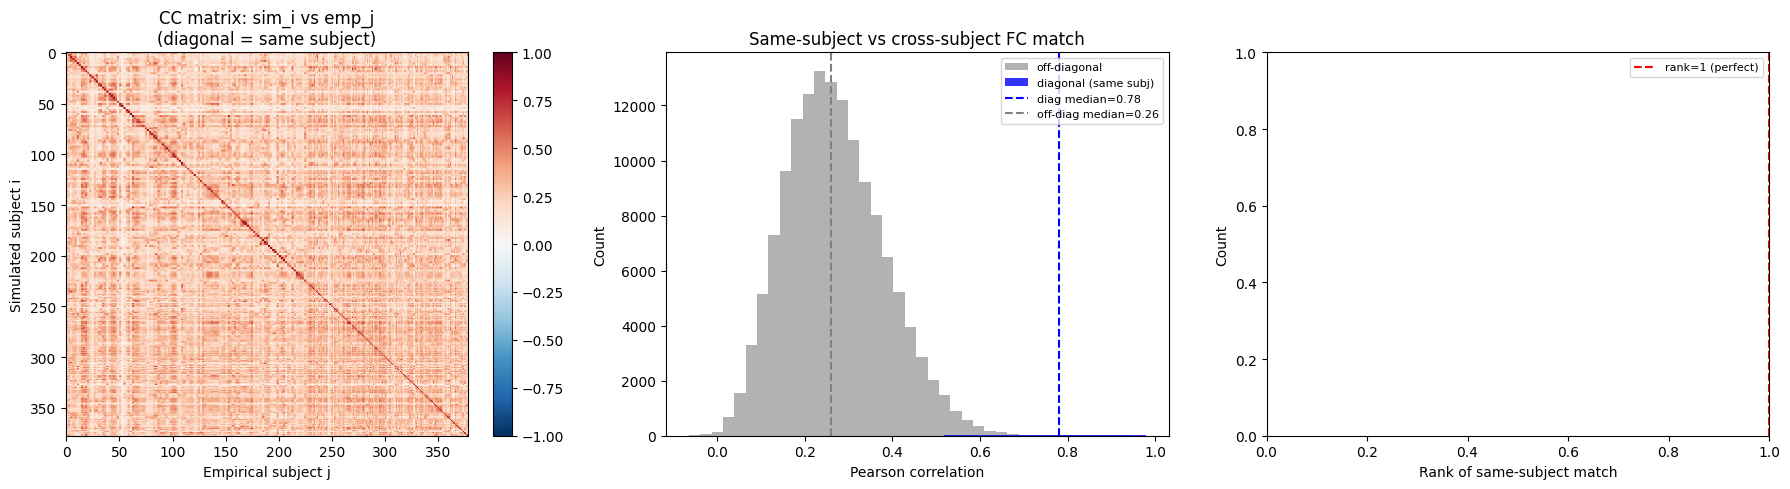


Same-subject FC corr  — median: 0.781  mean: 0.766
Cross-subject FC corr — median: 0.260  mean: 0.269


In [30]:
import numpy as np
import matplotlib.pyplot as plt

def compute_delayed_fc(data, delay):
    if delay == 0:
        return np.nan_to_num(np.corrcoef(data))
    lead = data[:, :-delay]
    lag  = data[:, delay:]
    corr = np.corrcoef(lead, lag)
    return np.nan_to_num(corr[data.shape[0]:, :data.shape[0]])


times_to_skip = 10
max_delay     = 40
num_examples  = 20
P             = len(Y_coll)

all_corr          = []
all_corr_ref      = []
all_corr_ref_top  = []

# ============================================================
# Cross-subject FC matrix at delay=0
# cc_matrix[i, j] = corr(FC_sim_i, FC_emp_j)
# Diagonal = same-subject match (should be maximum per row)
# ============================================================
cc_matrix = np.zeros((P, P))

fc_emp_flat_all = []   # store all empirical FC for cross-subject comparison
fc_sim_flat_all = []   # store all simulated FC

for patient in range(P):
    emp = Y_coll[patient][:, times_to_skip:].T         # [N, T]
    sim = Y_coll_sim[patient][times_to_skip:, :]     # [N, T]
    fc_emp_flat_all.append(compute_delayed_fc(emp, 0).flatten())
    fc_sim_flat_all.append(compute_delayed_fc(sim, 0).flatten())

# Fill cross-subject matrix
for i in range(P):
    for j in range(P):
        cc_matrix[i, j] = np.corrcoef(
            fc_sim_flat_all[i],
            fc_emp_flat_all[j]
        )[0, 1]

# ============================================================
# Plot 3 — cross-subject FC correlation matrix  (delay=0)
# Diagonal should be the maximum of each row
# ============================================================
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

im = ax[0].imshow(cc_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax[0].set_title("CC matrix: sim_i vs emp_j\n(diagonal = same subject)")
ax[0].set_xlabel("Empirical subject j")
ax[0].set_ylabel("Simulated subject i")
plt.colorbar(im, ax=ax[0])

# Diagonal vs off-diagonal distributions
diag_vals    = np.diag(cc_matrix)
offdiag_vals = cc_matrix[~np.eye(P, dtype=bool)]
ax[1].hist(offdiag_vals, bins=40, alpha=0.6, color='gray',  label='off-diagonal')
ax[1].hist(diag_vals,    bins=20, alpha=0.8, color='blue',  label='diagonal (same subj)')
ax[1].axvline(np.median(diag_vals),    color='blue', linestyle='--',
              label=f'diag median={np.median(diag_vals):.2f}')
ax[1].axvline(np.median(offdiag_vals), color='gray', linestyle='--',
              label=f'off-diag median={np.median(offdiag_vals):.2f}')
ax[1].set_xlabel("Pearson correlation"); ax[1].set_ylabel("Count")
ax[1].set_title("Same-subject vs cross-subject FC match")
ax[1].legend(fontsize=8)


ax[2].axvline(1, color='red', linestyle='--', label='rank=1 (perfect)')
ax[2].set_xlabel("Rank of same-subject match")
ax[2].set_ylabel("Count")

ax[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nSame-subject FC corr  — median: {np.median(diag_vals):.3f}  "
      f"mean: {np.mean(diag_vals):.3f}")
print(f"Cross-subject FC corr — median: {np.median(offdiag_vals):.3f}  "
      f"mean: {np.mean(offdiag_vals):.3f}")
